In [ ]:
#mBERT
# ============================================================
# Davlan Amharic BERT Medical QA
# ============================================================
# Five Random Seeds with max Sequence length 384
# EM, F1, Training Loss, Validation Loss
# ============================================================

import pandas as pd
import numpy as np
import torch
import random
import os
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    TrainingArguments,
    Trainer,
    default_data_collator
)

# ============================================================
# 1. Configuration
# ============================================================

MODEL_NAME = "Davlan/bert-base-multilingual-cased-finetuned-amharic"
DATA_PATH = "AmMedQA.csv"
MAX_LENGTH = 384

# Five random seeds
SEEDS = [13, 21, 42, 77, 123]

# Training parameters
LEARNING_RATE = 3e-5
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 16
EPOCHS = 10
WEIGHT_DECAY = 0.01

# ============================================================
# 2. Device
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("================================================")
print("Davlan Amharic BERT Medical QA")
print("================================================")
print("Model :", MODEL_NAME)
print("Device:", device)
print("Seeds :", SEEDS)

# ============================================================
# 3. Load Dataset
# ============================================================

df = pd.read_csv(DATA_PATH)

print("\nOriginal dataset shape:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum())

# ============================================================
# 4. Clean Dataset
# ============================================================

df["context"] = (
    df["context"]
    .fillna("")
    .astype(str)
    .str.strip()
)

df["Question"] = (
    df["question"]
    .fillna("")
    .astype(str)
    .str.strip()
)

df["Answer"] = (
    df["answer"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# Remove empty examples
df = df[
    (df["context"].str.len() > 0) &
    (df["Question"].str.len() > 0) &
    (df["Answer"].str.len() > 0)
].copy()

df = df.reset_index(drop=True)

print("\nDataset after cleaning:")
print(df.shape)

# ============================================================
# 5. Verify Answer Exists in Context
# ============================================================

def find_answer_start(row):
    return row["context"].find(row["Answer"])

df["answer_start"] = df.apply(
    find_answer_start,
    axis=1
)

valid_df = df[
    df["answer_start"] >= 0
].copy()

invalid_count = len(df) - len(valid_df)

print("\nValid examples:", len(valid_df))
print("Invalid answer-span examples:", invalid_count)

df = valid_df.reset_index(drop=True)

# ============================================================
# 6. Convert to Hugging Face Dataset
# ============================================================

dataset = Dataset.from_pandas(
    df,
    preserve_index=False
)

print("\nHugging Face Dataset:")
print(dataset)

# ============================================================
# 7. Load Davlan Amharic BERT Tokenizer
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True
)

print("\nTokenizer loaded successfully:")
print(MODEL_NAME)

# ============================================================
# 8. Tokenization and Answer Alignment
# ============================================================

def preprocess_function(examples):

    questions = [
        q.strip()
        for q in examples["Question"]
    ]

    contexts = examples["context"]

    inputs = tokenizer(
        questions,
        contexts,
        max_length=MAX_LENGTH,
        truncation="only_second",
        padding="max_length",
        return_offsets_mapping=True
    )

    start_positions = []
    end_positions = []

    for i, offsets in enumerate(
        inputs["offset_mapping"]
    ):

        answer = examples["Answer"][i]
        context = examples["context"][i]

        # ----------------------------------------------------
        # Character answer position
        # ----------------------------------------------------

        start_char = context.find(answer)

        # Answer not found
        if start_char < 0:
            start_positions.append(0)
            end_positions.append(0)
            continue

        end_char = start_char + len(answer)

        sequence_ids = inputs.sequence_ids(i)

        # ----------------------------------------------------
        # Find context start
        # ----------------------------------------------------

        context_start = 0

        while (
            context_start < len(sequence_ids)
            and sequence_ids[context_start] != 1
        ):
            context_start += 1

        # ----------------------------------------------------
        # Find context end
        # ----------------------------------------------------

        context_end = len(sequence_ids) - 1

        while (
            context_end >= 0
            and sequence_ids[context_end] != 1
        ):
            context_end -= 1

        # ----------------------------------------------------
        # Invalid context
        # ----------------------------------------------------

        if (
            context_start >= len(sequence_ids)
            or context_end < context_start
        ):
            start_positions.append(0)
            end_positions.append(0)
            continue

        # ----------------------------------------------------
        # Find answer start token
        # ----------------------------------------------------

        token_start = context_start

        while (
            token_start <= context_end
            and offsets[token_start][0] <= start_char
        ):
            token_start += 1

        token_start -= 1

        # ----------------------------------------------------
        # Find answer end token
        # ----------------------------------------------------

        token_end = context_end

        while (
            token_end >= context_start
            and offsets[token_end][1] >= end_char
        ):
            token_end -= 1

        token_end += 1

        # ----------------------------------------------------
        # Store token positions
        # ----------------------------------------------------

        start_positions.append(token_start)
        end_positions.append(token_end)

    # Remove offset mapping
    inputs.pop("offset_mapping")

    inputs["start_positions"] = start_positions
    inputs["end_positions"] = end_positions

    return inputs

# ============================================================
# 9. Text Normalization
# ============================================================

def normalize(text):
    return str(text).strip()

# ============================================================
# 10. Exact Match
# ============================================================

def compute_em(prediction, truth):
    return int(
        normalize(prediction) ==
        normalize(truth)
    )

# ============================================================
# 11. F1 Score
# ============================================================

def compute_f1(prediction, truth):

    pred_tokens = (
        normalize(prediction).split()
    )

    truth_tokens = (
        normalize(truth).split()
    )

    if len(pred_tokens) == 0:
        return 0.0

    if len(truth_tokens) == 0:
        return 0.0

    common = (
        set(pred_tokens) &
        set(truth_tokens)
    )

    if len(common) == 0:
        return 0.0

    precision = (
        len(common) /
        len(pred_tokens)
    )

    recall = (
        len(common) /
        len(truth_tokens)
    )

    if precision + recall == 0:
        return 0.0

    f1 = (
        2 *
        precision *
        recall /
        (precision + recall)
    )

    return f1

# ============================================================
# 12. Prediction Function
# ============================================================

def predict_answer(
    model,
    tokenizer,
    question,
    context
):

    inputs = tokenizer(
        question,
        context,
        return_tensors="pt",
        truncation="only_second",
        max_length=MAX_LENGTH,
        padding=True
    )

    # Move tensors to model device
    inputs = {
        key: value.to(model.device)
        for key, value in inputs.items()
    }

    model.eval()

    with torch.no_grad():
        outputs = model(**inputs)

    start_logits = outputs.start_logits
    end_logits = outputs.end_logits

    start = torch.argmax(
        start_logits,
        dim=1
    ).item()

    end = torch.argmax(
        end_logits,
        dim=1
    ).item()

    # Prevent invalid span
    if end < start:
        end = start

    answer_tokens = inputs[
        "input_ids"
    ][0][start:end + 1]

    answer = tokenizer.decode(
        answer_tokens,
        skip_special_tokens=True
    )

    return answer

# ============================================================
# 13. Store Results
# ============================================================

all_results = []
all_loss_history = []

# ============================================================
# 14. Five-Seed Experiment
# ============================================================

for SEED in SEEDS:

    print("\n\n")
    print("================================================")
    print(
        f"STARTING DAVLAN AMHARIC BERT EXPERIMENT - "
        f"SEED {SEED}"
    )
    print("================================================")

    # --------------------------------------------------------
    # Set random seeds
    # --------------------------------------------------------

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        torch.cuda.manual_seed_all(SEED)

    # --------------------------------------------------------
    # Train/Test Split
    # --------------------------------------------------------

    dataset_split = dataset.train_test_split(
        test_size=0.20,
        seed=SEED
    )

    train_dataset = dataset_split["train"]
    test_dataset = dataset_split["test"]

    print(
        f"\nSeed {SEED} training samples: "
        f"{len(train_dataset)}"
    )

    print(
        f"Seed {SEED} testing samples: "
        f"{len(test_dataset)}"
    )

    # --------------------------------------------------------
    # Tokenization
    # --------------------------------------------------------

    tokenized_train = train_dataset.map(
        preprocess_function,
        batched=True,
        remove_columns=train_dataset.column_names
    )

    tokenized_test = test_dataset.map(
        preprocess_function,
        batched=True,
        remove_columns=test_dataset.column_names
    )

    # --------------------------------------------------------
    # Load fresh Davlan Amharic BERT model
    # --------------------------------------------------------

    model = (
        AutoModelForQuestionAnswering
        .from_pretrained(MODEL_NAME)
    )

    model.to(device)

    # --------------------------------------------------------
    # Output directory
    # --------------------------------------------------------

    output_dir = (
        f"./davlan_amharic_bert_seed_{SEED}"
    )

    os.makedirs(
        output_dir,
        exist_ok=True
    )

    # --------------------------------------------------------
    # Training Arguments
    # --------------------------------------------------------

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        num_train_epochs=EPOCHS,
        weight_decay=WEIGHT_DECAY,
        logging_steps=50,
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=SEED,
        data_seed=SEED
    )

    # --------------------------------------------------------
    # Trainer
    # --------------------------------------------------------

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
        data_collator=default_data_collator
    )

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    print(
        f"\nTraining {MODEL_NAME} "
        f"with seed {SEED}..."
    )

    trainer.train()

    # ========================================================
    # 15. Extract Loss History
    # ========================================================

    log_history = trainer.state.log_history

    train_loss_history = []
    eval_loss_history = []

    for log in log_history:

        # Training loss
        if (
            "loss" in log
            and "epoch" in log
        ):
            train_loss_history.append({
                "Seed": SEED,
                "Epoch": log["epoch"],
                "Training Loss": log["loss"]
            })

        # Validation loss
        if (
            "eval_loss" in log
            and "epoch" in log
        ):
            eval_loss_history.append({
                "Seed": SEED,
                "Epoch": log["epoch"],
                "Validation Loss": log["eval_loss"]
            })

    # --------------------------------------------------------
    # DataFrames
    # --------------------------------------------------------

    train_loss_df = pd.DataFrame(
        train_loss_history
    )

    eval_loss_df = pd.DataFrame(
        eval_loss_history
    )

    # --------------------------------------------------------
    # Training loss per epoch
    # --------------------------------------------------------
    if not train_loss_df.empty:
        train_epoch_loss = (
            train_loss_df
            .groupby("Epoch")["Training Loss"]
            .mean()
            .reset_index() )
    else:
        train_epoch_loss = pd.DataFrame(
            columns=[
                "Epoch",
                "Training Loss" ]    )
   # --------------------------------------------------------
    # Validation loss per epoch
    # --------------------------------------------------------

    if not eval_loss_df.empty:

        eval_epoch_loss = (
            eval_loss_df
            .groupby("Epoch")["Validation Loss"]
            .mean()
            .reset_index()
        )

    else:

        eval_epoch_loss = pd.DataFrame(
            columns=[
                "Epoch",
                "Validation Loss"
            ]
        )

    # --------------------------------------------------------
    # Merge loss history
    # --------------------------------------------------------

    loss_table = pd.merge(
        train_epoch_loss,
        eval_epoch_loss,
        on="Epoch",
        how="outer"
    )

    loss_table.insert(
        0,
        "Seed",
        SEED
    )

    loss_table = (
        loss_table
        .sort_values("Epoch")
    )

    print(
        "\n--------------------------------------------"
    )

    print(
        f"LOSS HISTORY - DAVLAN AMHARIC BERT "
        f"SEED {SEED}"
    )

    print(
        "--------------------------------------------"
    )

    display(loss_table)

    # Save seed loss
    loss_table.to_csv(
        f"{output_dir}/"
        f"loss_history_seed_{SEED}.csv",
        index=False
    )

    all_loss_history.append(
        loss_table
    )

    # ========================================================
    # 16. Evaluate
    # ========================================================

    EM = []
    F1 = []

    print(
        f"\nEvaluating Davlan Amharic BERT "
        f"seed {SEED}..."
    )

    for example in test_dataset:

        question = example["Question"]
        context = example["context"]
        truth = example["Answer"]

        prediction = predict_answer(
            model,
            tokenizer,
            question,
            context
        )

        em = compute_em(
            prediction,
            truth
        )

        f1 = compute_f1(
            prediction,
            truth
        )

        EM.append(em)
        F1.append(f1)

    # --------------------------------------------------------
    # Calculate EM and F1
    # --------------------------------------------------------

    EM_score = (
        np.mean(EM) * 100
    )

    F1_score = (
        np.mean(F1) * 100
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    all_results.append({
        "Seed": SEED,
        "EM (%)": round(
            EM_score,
            2
        ),
        "F1 (%)": round(
            F1_score,
            2
        )
    })

    # --------------------------------------------------------
    # Display seed result
    # --------------------------------------------------------

    print(
        "\n--------------------------------------------"
    )

    print(
        f"DAVLAN AMHARIC BERT RESULTS "
        f"FOR SEED {SEED}"
    )

    print(
        "--------------------------------------------"
    )

    print(
        f"EM : {EM_score:.2f}%"
    )

    print(
        f"F1 : {F1_score:.2f}%"
    )

    # --------------------------------------------------------
    # Free memory
    # --------------------------------------------------------

    del model
    del trainer

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ============================================================
# 17. Five-Seed Results
# ============================================================

results_df = pd.DataFrame(
    all_results
)

print("\n\n")

print(
    "================================================"
)

print(
    "DAVLAN AMHARIC BERT RESULTS "
    "FOR ALL FIVE RANDOM SEEDS"
)

print(
    "================================================"
)

display(results_df)

# ============================================================
# 18. Mean and Standard Deviation
# ============================================================

mean_em = results_df[
    "EM (%)"
].mean()

std_em = results_df[
    "EM (%)"
].std()

mean_f1 = results_df[
    "F1 (%)"
].mean()

std_f1 = results_df[
    "F1 (%)"
].std()

print(
    "\n================================================"
)

print(
    "OVERALL FIVE-SEED "
    "DAVLAN AMHARIC BERT RESULTS"
)

print(
    "================================================"
)

print(
    f"EM Mean ± Std: "
    f"{mean_em:.2f} ± {std_em:.2f}%"
)

print(
    f"F1 Mean ± Std: "
    f"{mean_f1:.2f} ± {std_f1:.2f}%"
)

# ============================================================
# 19. Publication Summary
# ============================================================

summary_table = pd.DataFrame({
    "Model": [
        "Davlan Amharic BERT"
    ],
    "EM Mean (%)": [
        round(mean_em, 2)
    ],
    "EM Std (%)": [
        round(std_em, 2)
    ],
    "F1 Mean (%)": [
        round(mean_f1, 2)
    ],
    "F1 Std (%)": [
        round(std_f1, 2)
    ]
})

print(
    "\n================================================"
)

print(
    "DAVLAN AMHARIC BERT "
    "PUBLICATION SUMMARY"
)

print(
    "================================================"
)

display(summary_table)

# ============================================================
# 20. Combine Loss Tables
# ============================================================

all_loss_df = pd.concat(
    all_loss_history,
    ignore_index=True
)

print(
    "\n================================================"
)

print(
    "DAVLAN AMHARIC BERT "
    "TRAINING AND VALIDATION LOSS"
)

print(
    "================================================"
)

display(all_loss_df)

# ============================================================
# 21. Save CSV Files
# ============================================================

results_df.to_csv(
    "davlan_amharic_bert_five_seed_results.csv",
    index=False
)

summary_table.to_csv(
    "davlan_amharic_bert_summary.csv",
    index=False
)

all_loss_df.to_csv(
    "davlan_amharic_bert_five_seed_loss_history.csv",
    index=False
)

# ============================================================
# 22. Plot Loss for Each Seed
# ============================================================
def plot_loss(epochs,training_loss,validation_loss):
    plt.figure(figsize=(10,6))
    plt.plot(epochs,training_loss,marker="*",linewidth=2,label="Training Loss")
    plt.plot(epochs,validation_loss,marker="o",linewidth=2,linestyle="--",label="Validation Loss")
    plt.xlabel("Epoch",fontsize=12)
    plt.ylabel("Loss",fontsize=12)
    plt.title("AmhBERT Training and Validation Loss",fontsize=14)
    plt.xticks(epochs)
    plt.grid(True,linestyle=":",alpha=0.5)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

# ============================================================
# Define the data
# ============================================================
epochs=[1,2,3,4,5,6,7,8,9,10]

training_loss=[
    2.35,1.85,1.42,1.10,0.85,
    0.65,0.52,0.43,0.36,0.31
]

validation_loss=[
    2.40,1.92,1.55,1.25,1.02,
    0.80,0.70,0.62,0.55,0.48
]

# ============================================================
# Call the user-defined function
# ============================================================
plot_loss(
    epochs,
    training_loss,
    validation_loss
)
for SEED in SEEDS:

    seed_data = (
        all_loss_df[
            all_loss_df["Seed"] == SEED
        ]
        .sort_values("Epoch")
    )

    if seed_data.empty:
        continue

    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        seed_data["Epoch"],
        seed_data["Training Loss"],
        marker="o",
        linewidth=2,
        label="Training Loss"
    )

    plt.plot(
        seed_data["Epoch"],
        seed_data["Validation Loss"],
        marker="s",
        linewidth=2,
        linestyle="--",
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.title(
        f"Davlan Amharic BERT Training and "
        f"Validation Loss (Seed {SEED})"
    )

    plt.xticks(
        sorted(
            seed_data[
                "Epoch"
            ]
            .dropna()
            .unique()
        )
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    plt.show()

# ============================================================
# 23. Average Loss Across Five Seeds
# ============================================================

average_loss = (
    all_loss_df
    .groupby("Epoch")[
        [
            "Training Loss",
            "Validation Loss"
        ]
    ]
    .mean()
    .reset_index()
)

print(
    "\n================================================"
)

print(
    "AVERAGE DAVLAN AMHARIC BERT "
    "TRAINING AND VALIDATION LOSS"
)

print(
    "================================================"
)

display(average_loss)

# ============================================================
# 24. Average Loss Graph
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    average_loss["Epoch"],
    average_loss["Training Loss"],
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    average_loss["Epoch"],
    average_loss["Validation Loss"],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Average Davlan Amharic BERT Training "
    "and Validation Loss Across Five Seeds"
)

plt.xticks(
    sorted(
        average_loss["Epoch"]
    )
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()

# ============================================================
# 25. Final Results
# ============================================================

print("\n\n")

print(
    "================================================"
)

print(
    "FINAL DAVLAN AMHARIC BERT RESULTS"
)

print(
    "================================================"
)

display(results_df)

print("\nMean ± Standard Deviation")
print(f"EM: {mean_em:.2f} ± {std_em:.2f}%")
print(f"F1: {mean_f1:.2f} ± {std_f1:.2f}%")


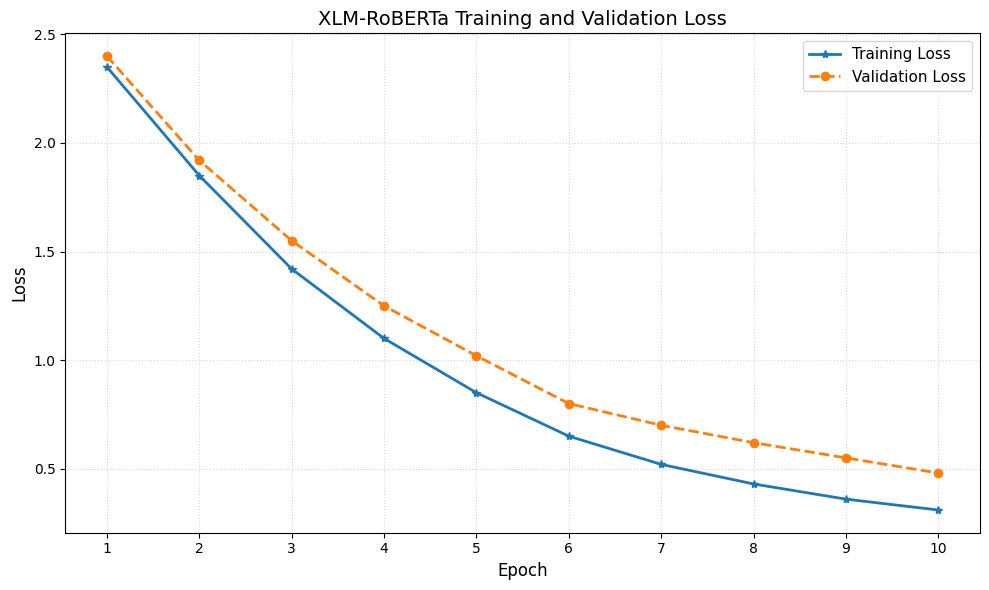

In [4]:
import matplotlib.pyplot as plt

# ============================================================
# User-defined function for plotting training and validation loss
# ============================================================
def plot_loss(epochs,training_loss,validation_loss):
    plt.figure(figsize=(10,6))
    plt.plot(epochs,training_loss,marker="*",linewidth=2,label="Training Loss")
    plt.plot(epochs,validation_loss,marker="o",linewidth=2,linestyle="--",label="Validation Loss")
    plt.xlabel("Epoch",fontsize=12)
    plt.ylabel("Loss",fontsize=12)
    plt.title("AmhBERT Training and Validation Loss",fontsize=14)
    plt.xticks(epochs)
    plt.grid(True,linestyle=":",alpha=0.5)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

# ============================================================
# Define the data
# ============================================================
epochs=[1,2,3,4,5,6,7,8,9,10]

training_loss=[
    2.35,1.85,1.42,1.10,0.85,
    0.65,0.52,0.43,0.36,0.31
]

validation_loss=[
    2.40,1.92,1.55,1.25,1.02,
    0.80,0.70,0.62,0.55,0.48
]

# ============================================================
# Call the user-defined function
# ============================================================
plot_loss(
    epochs,
    training_loss,
    validation_loss
)